<a href="https://colab.research.google.com/github/pyingqi18/ECON5314G/blob/main/CASI_chapter_3_bayesian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3 Bayesian Inference

## 3.1 Two examples

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

In [3]:
data = pd.read_csv("student_score.txt", delimiter = " ")
# data.describe()
data.tail()

,mech,vecs,alg,analy,stat
17,48,38,41,44,33
18,31,42,48,54,68
19,42,69,61,55,45
20,46,49,53,59,37
21,63,63,65,70,63


In [4]:
x1 = data.mech
x2 = data.vecs
x3 = data.alg

### Frequentist

In [5]:
((x1-x1.mean())*(x2-x2.mean())).sum()/np.sqrt(((x1-x1.mean())**2).sum()*((x2-x2.mean())**2).sum())

np.float64(0.49780749859167384)

In [7]:
# np.corrcoef((x1,x2,x3))
np.corrcoef((x1,x2,x3))[0,1]

np.float64(0.49780749859167395)

### Bayesian

#### Recall the Bayes' rule

Given the prior density of $\theta$, $g(\theta)$,  apply the Bayes' rule, we have:
\begin{align}
g(\theta|\hat\theta) = g(\theta)\frac{f(\hat\theta|\theta)}{f(\hat\theta)},
\end{align}

where the marginal density of $\hat\theta$, $f(\hat\theta)$, is given by
\begin{align*}
f(\hat\theta)
&= \int_{[-1,1]} f(\hat\theta|\theta)g(\theta) d\theta
\end{align*}

#### Preparations

In [8]:
import math
from scipy.integrate import quad, nquad

In [9]:
pi = math.pi
n = 22
theta_hat = np.corrcoef(x1,x2)[1,0]
theta_hat

np.float64(0.497807498591674)

#### The conditional density of the data given the parameter, $f(x|\theta)$

The conditional density of $\hat\theta$ on $\theta$ (equivalently $x$) is given by
\begin{align}
f(\hat{\theta}|\theta) = \frac{(n - 2)(1 - \theta^2)^{(n - 1) / 2}(1 - \hat{\theta}^2)^{(n - 4)/2}}{\pi} \int_0^\infty \frac{dw}{(\cosh w - \theta \hat{\theta})^{n - 1}}
\end{align}
where $n = 22$ (see page 27 of the CASI book).  

In [10]:
def f_cond(theta_hat, theta):
    int_out = (n-2)*(1-theta**2)**((n-1)/2)*(1-theta_hat**2)**((n-4)/2) / pi

    intgral, err = quad(lambda w: 1/(math.cosh(w) - theta*theta_hat)**(n-1), 0, 10)

    return int_out*intgral

In [ ]:
# def f_cond(theta_hat, theta):

#     int_out = (n-2)*(1-theta**2)**((n-1)/2)*(1-theta_hat**2)**((n-4)/2) / pi

#     intgral, err = quad(lambda w: 1/(math.cosh(w) - theta*theta_hat)**(n-1), 0, 10)

#     return int_out*intgral

In [ ]:
# def f_cond(theta_hat,theta):
#     int_out = (n-2)*(1-theta**2)**((n-1)/2)*(1-theta_hat**2)**((n-4)/2)/pi
#     intgral, err = quad(lambda w: 1/((math.cosh(w)-theta*theta_hat))**(n-1), 0.0, 10)
#     return int_out*intgral

In [11]:
theta = 0.9

int_out = (n-2)*(1-theta**2)**((n-1)/2)*(1-theta_hat**2)**((n-4)/2)/pi
intgral, err = quad(lambda w: 1/((math.cosh(w)-theta*theta_hat))**(n-1), 0.000, 10)
print(intgral*int_out)

0.0007107647126495982


In [12]:
f_cond(theta_hat, 0.0)

np.float64(0.13581090878777274)

In [15]:
f_cond(0.1,0.5)

0.22472797475482773

In [14]:
f_cond(0.2,0.5)

0.5162697322483332

#### Specify the prior $g(\theta)$

In [16]:
g = 1/2

#### Calculate the marginal distribution $f(\hat\theta)$

The marginal density of $\hat\theta$, $f(\hat\theta)$, is given by
\begin{align*}
f(\hat\theta)
&= \int_{[-1,1]} f(\hat\theta|\theta)g(\theta) d\theta
\end{align*}

In [17]:
integrand = lambda theta:f_cond(theta_hat, theta)*g
y, err = quad(integrand, -1, 1)
f_thetahat_flat = y

In [ ]:
# f_thetahat_flat, err = quad(lambda theta: f_cond(theta_hat, theta)*g, -1, 1)

In [19]:
f_thetahat_flat

0.4885129090896332

#### Apply Bayes' rule to get the posterior $g(\theta|\hat\theta)$

In [20]:
post_flat = lambda theta: g*f_cond(theta_hat, theta)/f_thetahat_flat

In [ ]:
# post_flat = lambda theta: g*f_cond(theta_hat,theta)/f_thetahat_flat

#### Plot $g(\theta|\hat\theta)$

In [22]:
x_theta = np.arange(-0.2, 0.99, 0.01)
# x_theta

In [23]:
y_flat = np.zeros(len(x_theta))

for i in range(len(x_theta)):
    y_flat[i] = post_flat(x_theta[i])

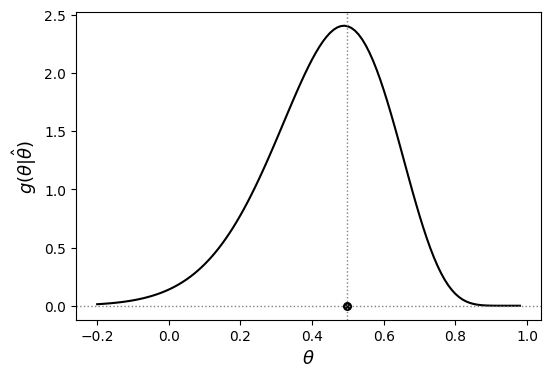

In [24]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(x_theta, y_flat, "k-")
ax.scatter([theta_hat], [0], c="k", s=30)
ax.axhline(0, c="gray", linestyle=":", linewidth=1)
ax.axvline(theta_hat, c="gray", linestyle=":", linewidth=1)

ax.set_xlabel(r"$\theta$", size=13)
ax.set_ylabel(r"$g(\theta|\hat{\theta})$", size=13)

plt.show()